# Model Demonstration

A demonstration of the saved TriCondNet ensemble. Feed in a chemical formula string, convert
it to a CBFV, and append the temperature range you want to simulate; the prediction is
plotted with an uncertainty band from the spread across ensemble members. Note that the
dataset shipped here is small, so results may not be accurate for every composition. The
ensemble interpolates between nearby compositions but won't extrapolate across structural
families, e.g. a model trained mainly on perovskites shouldn't be trusted on spinels. Supplement
it with your own data if you need a new chemistry.

In [10]:
import sys 
from pathlib import Path
import sys 
import io
import warnings
from contextlib import redirect_stdout
from torch import seed
sys.path.insert(0, str(Path.cwd().parent))
from models import deployment_tricondnet

Load the dataset you want to train on. To sanity-check the model against real measurements,
you can hold a formula out of the training set, retrain the ensemble without it, and then
predict it here. `deployment_tricondnet.remove_formula_from_training(data, cbfv, formulae)`
does the removal for you, writing the trimmed set to `temporary_data/training_{cbfv}.csv`.


With the models, we can now predict the formulae we're interested in and compare it to the actual data.

In [18]:
Example_Formulae = ["SrTi0.8Nb0.2O3", "La0.9Sr0.1CoO3"] # Example formulae not in the dataset
Temperatures = [300, 400, 500, 600, 700, 800, 900, 1000] # in Kelvin
CBFV_Chosen = "magpie"
Seed_Range = range(0, 20) # random states of the saved models

# Generating features for listed compositions 
with warnings.catch_warnings(), redirect_stdout(io.StringIO()):
    warnings.simplefilter("ignore")
    Data = deployment_tricondnet.convert_formula_to_features(Example_Formulae, Temperatures, cbfv=CBFV_Chosen)

if not Data.empty:
    print(f"Successfully featurised input formulae and temperatures. Num of samples is {Data.shape[0]}")

Assigning Features...: 100%|██████████| 1/1 [00:00<00:00, 4443.12it/s]

Successfully featurised input formulae and temperatures. Num of samples is 16


In [12]:

# Predicting conductivity on test set
DropCols = ["source", "entry",]
ReferenceDataFormula = Data["formula"]
Reference_Data = Data.drop(DropCols, axis=1)
root_path = Path.cwd() / "models" / CBFV_Chosen

# Loading the ensemble prints a banner for every model (20 seeds x 3 models) and
# scikit-learn warns about feature names on each classifier call. Neither is
# informative here, so both are muted to keep the output readable.
with warnings.catch_warnings(), redirect_stdout(io.StringIO()):
    warnings.simplefilter("ignore")
    ensemble = deployment_tricondnet.TriCondNet_Ensemble_Wrapper(Classifier_Root_Path=root_path, Semiconductor_Root_Path=root_path, Metal_Root_Path=root_path, seeds_list=Seed_Range)
    ensemble.load_data(test_df=Reference_Data)
    final_df = ensemble.ensemble(classifier_model_name=f"Ensemble_GBM_{CBFV_Chosen}", semiconductor_model_name="SemiconductorEnsemble", metal_model_name="MetalEnsemble")

print(f"Predicted {len(final_df)} rows across {final_df['formula'].nunique()} formulae.")

Predicted 16 rows across 2 formulae.


Converting formulae of interest to CBFV, appending temperature columns, and then simulating them.

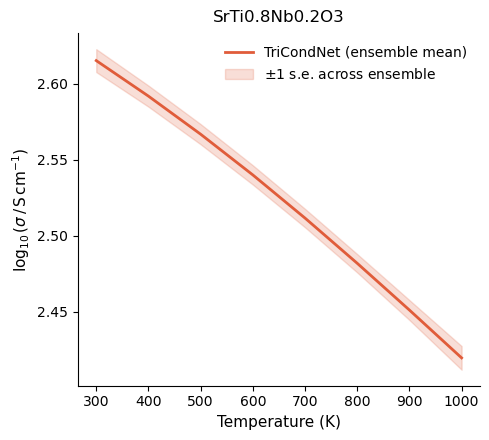

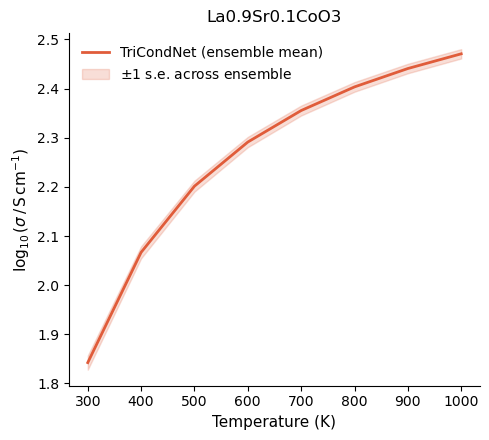

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# The ensemble returns one row per input row but drops the temperature column,
# so put it back to plot against.
final_df["temp"] = Reference_Data["temp"].reset_index(drop=True).values

c_pred = "#E05C3A"

for formula in Example_Formulae:
    # One temperature sweep per formula
    pred = final_df[final_df["formula"] == formula].sort_values("temp")

    # The ensemble reports conductivity in S/cm; the plot is in log10 space
    pred_log10 = np.log10(pred["pred_conductivity"])

    # regressor_uncertainty is the standard error across ensemble members
    pred_sem = pred["regressor_uncertainty"] / (np.log(10) * pred["pred_conductivity"])

    fig, ax = plt.subplots(figsize=(5, 4.5))

    # Mean prediction across the ensemble
    ax.plot(pred["temp"], pred_log10, color=c_pred, lw=2, zorder=4,
            label="TriCondNet (ensemble mean)")

    # Shaded band = +/- 1 standard error across the ensemble
    ax.fill_between(pred["temp"], pred_log10 - pred_sem, pred_log10 + pred_sem,
                    color=c_pred, alpha=0.20, zorder=3,
                    label=r"$\pm$1 s.e. across ensemble")

    ax.set_title(formula, fontsize=12, pad=8)
    ax.set_xlabel("Temperature (K)", fontsize=11)
    ax.set_ylabel(r"$\log_{10}(\sigma\,/\,\mathrm{S\,cm^{-1}})$", fontsize=11)
    ax.legend(frameon=False, fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(labelsize=10)

    fig.tight_layout()
    plt.show()
